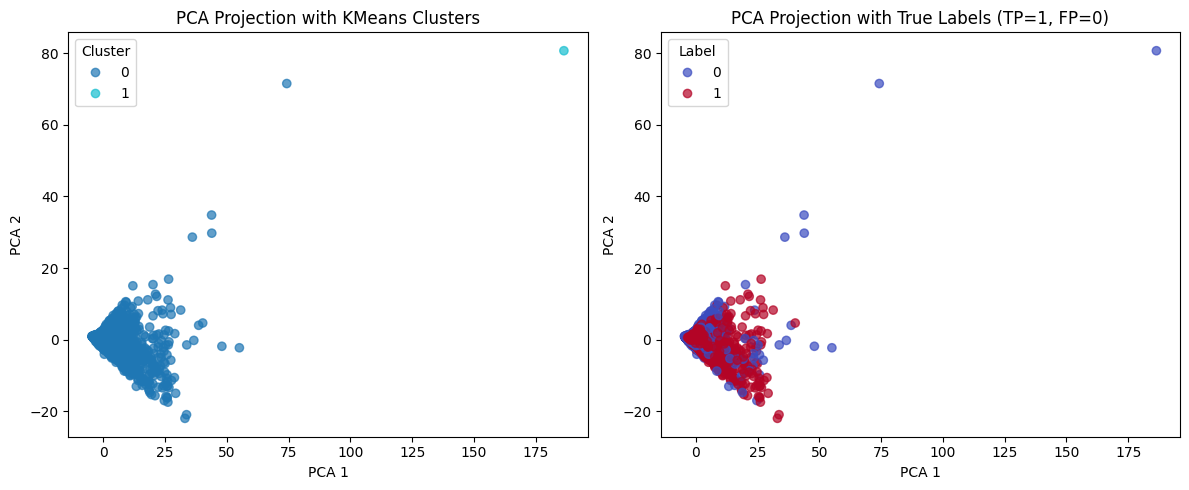

In [21]:
import numpy as np
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os
import pickle


events_path = "/home/honeynaps/data/GOLDEN/AROUS_SPEC/events"
events_files = os.listdir(events_path)


events_data = []
labels = []

for event_file in events_files:
    with open(os.path.join(events_path, event_file), 'rb') as f:
        events = pickle.load(f)
        events_data.extend(events['x'])
        labels.extend(events['y'])

# --------------------------------------------------
# 2. Feature Extraction 함수 정의
# --------------------------------------------------
def extract_features(events, fs=50):
    feats_list = []
    for ev in events:
        feats = []
        for ch in ev:
            # 시계열 통계
            feats.append(ch.mean())
            feats.append(ch.std())
            feats.append(np.sqrt(np.mean(ch**2)))  # RMS
            # Welch PSD
            f, Pxx = welch(ch, fs=fs, nperseg=fs*2)
            # Band-power (delta, theta, alpha, beta)
            bands = [(0.5,4),(4,8),(8,13),(13,30)]
            for (fmin, fmax) in bands:
                idx = np.logical_and(f>=fmin, f<=fmax)
                feats.append(Pxx[idx].sum())
        feats_list.append(feats)
    return np.array(feats_list)

# Feature matrix (n_events x n_features)
X = extract_features(events_data, fs=50)

# --------------------------------------------------
# 3. 스케일링 & 차원 축소 (PCA)
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 4. 클러스터링 (KMeans)
# --------------------------------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# --------------------------------------------------
# 5. 시각화
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# (1) 클러스터별 분포
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.7)
plt.title('PCA Projection with KMeans Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter.legend_elements(), title='Cluster')

# (2) 실제 레이블별 분포 (TP vs FP)
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm', alpha=0.7)
plt.title('PCA Projection with True Labels (TP=1, FP=0)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(*scatter2.legend_elements(), title='Label')

plt.tight_layout()
plt.show()


22674
[Epoch 1/20] Loss: 0.053654
[Epoch 2/20] Loss: 0.049001
[Epoch 3/20] Loss: 0.049001
[Epoch 4/20] Loss: 0.049001
[Epoch 5/20] Loss: 0.049001
[Epoch 6/20] Loss: 0.049001
[Epoch 7/20] Loss: 0.049001
[Epoch 8/20] Loss: 0.049001
[Epoch 9/20] Loss: 0.049001
[Epoch 10/20] Loss: 0.049001
[Epoch 11/20] Loss: 0.049001
[Epoch 12/20] Loss: 0.049001
[Epoch 13/20] Loss: 0.049001
[Epoch 14/20] Loss: 0.049001
[Epoch 15/20] Loss: 0.049001
[Epoch 16/20] Loss: 0.049001
[Epoch 17/20] Loss: 0.049001
[Epoch 18/20] Loss: 0.049001
[Epoch 19/20] Loss: 0.049001
[Epoch 20/20] Loss: 0.049001


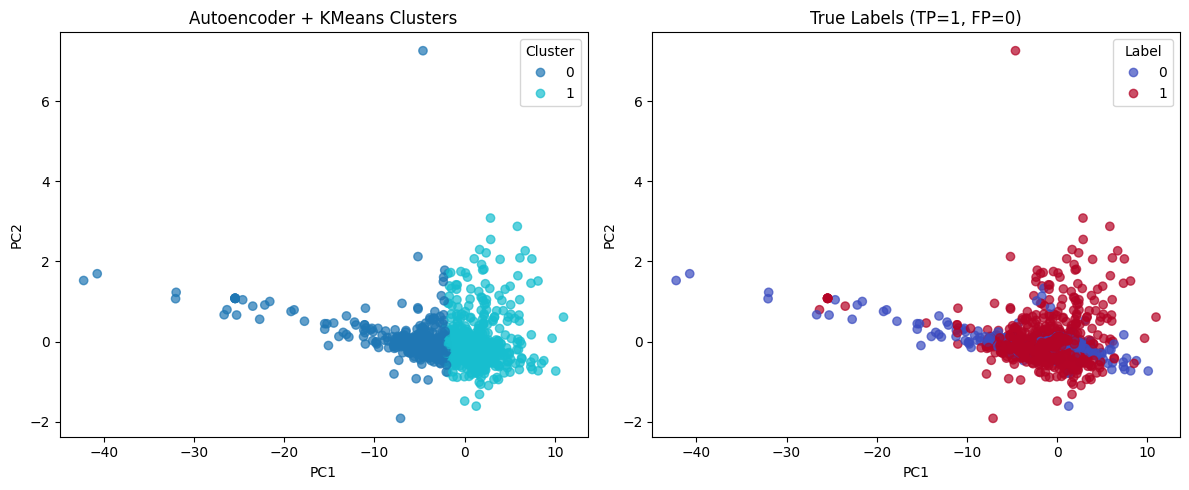

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


max_len = max(ev.shape[1] for ev in events_data)
def pad_truncate(ev, length):
    C, L = ev.shape
    if L >= length:
        return ev[:, :length]
    pad = np.zeros((C, length - L), dtype=ev.dtype)
    return np.concatenate([ev, pad], axis=1)
print(max_len)
X = np.stack([pad_truncate(ev, max_len) for ev in events_data])  # (N, C, T)
X = torch.tensor(X, dtype=torch.float32)


class EventDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        return self.data[idx]

batch_size = 16
dataset = EventDataset(X)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --------------------------------------------------
# 4) Define 1D Conv Autoencoder
# --------------------------------------------------

def center_crop_or_pad1d(x, target_len):
    """
    1D 버전 center_crop_or_pad:
    x: (B, C, L)
    target_len: 목표 길이
    """
    B, C, L = x.shape
    if L > target_len:
        diff = L - target_len
        start = diff // 2
        end = start + target_len
        return x[:, :, start:end]
    elif L < target_len:
        diff = target_len - L
        pad_before = diff // 2
        pad_after = diff - pad_before
        # pad format: (left, right)
        return F.pad(x, (pad_before, pad_after))
    return x

class Conv1dAutoencoder(nn.Module):
    def __init__(self, in_ch=9, latent_dim=32, max_input_len=2000):
        super().__init__()
        # Encoder 부분: stride=2 두 번 => 다운샘플
        self.encoder_conv = nn.Sequential(
            nn.Conv1d(in_ch,  64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.Conv1d(64,   128, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )
        # 더미 입력으로 실제 flatten 차원 및 다운샘플된 시퀀스 길이 계산
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, max_input_len)
            out   = self.encoder_conv(dummy)
            _, C_enc, L_enc = out.shape
            self._flatten_dim  = C_enc * L_enc
            self._enc_time_len = L_enc
        # Latent 변환 레이어
        self.fc_enc = nn.Linear(self._flatten_dim, latent_dim)
        # Decoder 복원용 FC
        self.fc_dec = nn.Linear(latent_dim, self._flatten_dim)
        # Decoder ConvTranspose
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(128,  64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, in_ch, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        x: (B, in_ch, L)
        returns:
          x_out: (B, in_ch, L) 입력 길이에 맞춰 cropping/padding 적용
          z:      (B, latent_dim)
        """
        B, _, L = x.shape
        # Encoder
        x_enc = self.encoder_conv(x)                 # (B, 128, L_enc)
        B, C_enc, L_enc = x_enc.shape
        x_flat = x_enc.view(B, -1)                   # (B, flatten_dim)
        z      = self.fc_enc(x_flat)                 # (B, latent_dim)
        # Decoder
        x_rec_flat = self.fc_dec(z)                  # (B, flatten_dim)
        x_rec      = x_rec_flat.view(B, C_enc, L_enc) # (B,128,L_enc)
        x_out      = self.decoder_conv(x_rec)        # (B,in_ch,L_dec)
        # 입력 길이 L에 맞춰 crop or pad
        x_out = center_crop_or_pad1d(x_out, L)
        return x_out, z
# --------------------------------------------------
# 5) Train Autoencoder
# --------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Conv1dAutoencoder(max_input_len=max_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model.train()
for epoch in range(20):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        rec, _ = model(batch)
        loss = criterion(rec, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    print(f"[Epoch {epoch+1}/20] Loss: {total_loss/len(dataset):.6f}")

# --------------------------------------------------
# 6) Extract Latent Features
# --------------------------------------------------
model.eval()
with torch.no_grad():
    z_all = []
    for batch in DataLoader(dataset, batch_size=batch_size):
        batch = batch.to(device)
        _, z = model(batch)
        z_all.append(z.cpu().numpy())
    Z = np.concatenate(z_all, axis=0)  # (N, latent_dim)

# --------------------------------------------------
# 7) Clustering (KMeans) on Latent
# --------------------------------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(Z)

# --------------------------------------------------
# 8) PCA for Visualization
# --------------------------------------------------
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

# --------------------------------------------------
# 9) Plot
# --------------------------------------------------
plt.figure(figsize=(12,5))

# Clusters
plt.subplot(1,2,1)
scatter1 = plt.scatter(Z_pca[:,0], Z_pca[:,1], c=clusters, cmap='tab10', alpha=0.7)
plt.title('Autoencoder + KMeans Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter1.legend_elements(), title='Cluster')

# True labels
plt.subplot(1,2,2)
scatter2 = plt.scatter(Z_pca[:,0], Z_pca[:,1], c=labels, cmap='coolwarm', alpha=0.7)
plt.title('True Labels (TP=1, FP=0)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter2.legend_elements(), title='Label')

plt.tight_layout()
plt.show()
